In [1]:
import numpy as np
import pandas as pd
from scipy.special import digamma, logsumexp, gammaln
from sklearn.mixture import BayesianGaussianMixture

class VARISEM:
    def __init__(self, X, K, max_iter=300, tol=1e-6, alpha_prior=None, a_prior=None, b_prior=None):
        self.X = X
        self.N, self.D = X.shape
        self.K = K
        self.max_iter = max_iter
        self.tol = tol

        # Priors
        self.alpha_prior = alpha_prior if alpha_prior is not None else np.ones(K) * 2
        self.a_prior = a_prior if a_prior is not None else np.ones((K, self.D)) * 2
        self.b_prior = b_prior if b_prior is not None else np.ones((K, self.D)) * 5

        # Initialize q_nk with BayesianGaussianMixture
        bmm = BayesianGaussianMixture(
            n_components=K,
            covariance_type="full",
            weight_concentration_prior_type="dirichlet_process",
            random_state=42,
            max_iter=100,
            n_init=10
        )
        bmm.fit(X)
        self.q_nk = bmm.predict_proba(X)

        # Initialize variational parameters
        self.alpha_q = self.alpha_prior + np.sum(self.q_nk, axis=0)
        self.a_q = self.a_prior + np.dot(self.q_nk.T, X)
        self.b_q = self.b_prior + np.dot(self.q_nk.T, 1 - X)

        self.pi_inferred_mean = None
        self.mu_inferred_mean = None
        self.cluster_assignments = None

        self.elbo_values = []

    def update_q_nk(self):
        log_pi_k = digamma(self.alpha_q) - digamma(np.sum(self.alpha_q))
        log_mu_ki = digamma(self.a_q) - digamma(self.a_q + self.b_q)
        log_1_mu_ki = digamma(self.b_q) - digamma(self.a_q + self.b_q)

        log_q_nk = log_pi_k + np.sum(
            self.X[:, None, :] * log_mu_ki[None, :, :] +
            (1 - self.X[:, None, :]) * log_1_mu_ki[None, :, :],
            axis=2
        )
        log_q_nk -= logsumexp(log_q_nk, axis=1, keepdims=True)
        self.q_nk = np.exp(log_q_nk)

    def update_pi_k(self):
        self.alpha_q = self.alpha_prior + np.sum(self.q_nk, axis=0)
        self.pi_inferred_mean = self.alpha_q / np.sum(self.alpha_q)

    def update_mu_ki(self):
        self.a_q = self.a_prior + np.dot(self.q_nk.T, self.X)
        self.b_q = self.b_prior + np.dot(self.q_nk.T, 1 - self.X)
        self.mu_inferred_mean = self.a_q / (self.a_q + self.b_q)

    def compute_elbo(self):
        log_mu_ki = digamma(self.a_q) - digamma(self.a_q + self.b_q)
        log_1_mu_ki = digamma(self.b_q) - digamma(self.a_q + self.b_q)

        log_likelihood = np.sum(self.q_nk[:, :, None] * (
            self.X[:, None, :] * log_mu_ki[None, :, :] +
            (1 - self.X[:, None, :]) * log_1_mu_ki[None, :, :]
        ))

        log_pi_k = digamma(self.alpha_q) - digamma(np.sum(self.alpha_q))
        log_prior_z = np.sum(self.q_nk * log_pi_k)
        log_prior_pi = np.sum((self.alpha_prior - 1) * log_pi_k)
        log_prior_mu = np.sum((self.a_prior - 1) * log_mu_ki + (self.b_prior - 1) * log_1_mu_ki)

        entropy_q_z = -np.sum(self.q_nk * np.log(self.q_nk + 1e-10))
        alpha_0 = np.sum(self.alpha_q)
        dirichlet_entropy = (
            gammaln(alpha_0) - np.sum(gammaln(self.alpha_q)) +
            (alpha_0 - self.K) * digamma(alpha_0) -
            np.sum((self.alpha_q - 1) * digamma(self.alpha_q))
        )
        beta_entropy = np.sum(
            gammaln(self.a_q + self.b_q) -
            gammaln(self.a_q) -
            gammaln(self.b_q) -
            (self.a_q - 1) * digamma(self.a_q) -
            (self.b_q - 1) * digamma(self.b_q) +
            (self.a_q + self.b_q - 2) * digamma(self.a_q + self.b_q)
        )

        elbo = (
            log_likelihood +
            log_prior_z +
            log_prior_pi +
            log_prior_mu +
            entropy_q_z +
            dirichlet_entropy +
            beta_entropy
        )
        return elbo

    def fit(self):
        elbo_old = -np.inf
        self.elbo_values = []

        for iteration in range(self.max_iter):
            self.update_q_nk()
            self.update_pi_k()
            self.update_mu_ki()

            elbo = self.compute_elbo()
            self.elbo_values.append(elbo)

            if np.abs(elbo - elbo_old) < self.tol:
                print(f"Converged at iteration {iteration}, ELBO: {elbo:.4f}")
                break

            elbo_old = elbo

            if iteration % 10 == 0 or iteration == self.max_iter - 1:
                print(f"Iteration {iteration}, ELBO: {elbo:.4f}")

        self.cluster_assignments = np.argmax(self.q_nk, axis=1)

    def predict(self):
        if self.cluster_assignments is None:
            raise ValueError("Model not yet fitted. Run .fit() first.")
        return self.cluster_assignments

    def get_results(self):
        if self.pi_inferred_mean is None or self.mu_inferred_mean is None:
            raise ValueError("Model not yet fitted. Run .fit() first.")

        return {
            "pi_inferred_mean": self.pi_inferred_mean,
            "mu_inferred_mean": self.mu_inferred_mean,
            "cluster_assignments": self.cluster_assignments,
            "elbo_values": self.elbo_values
        }

    def save_results(self, pi_filename="pi_inferred_mean.csv",
                     mu_filename="mu_inferred_mean.csv",
                     cluster_filename="VARISEM_cluster_assignments.csv"):
        """
        Save inferred parameters and cluster assignments to separate CSV files.

        Args:
            pi_filename (str): CSV file path to save pi (cluster proportions).
            mu_filename (str): CSV file path to save mu (mutation probabilities).
            cluster_filename (str): CSV file path to save predicted cluster assignments.
        """
        if self.pi_inferred_mean is None or self.mu_inferred_mean is None or self.cluster_assignments is None:
            raise ValueError("Model not yet fitted. Run .fit() first.")

        # Save pi (cluster proportions)
        pi_df = pd.DataFrame([self.pi_inferred_mean], columns=[f"Cluster_{k}" for k in range(self.K)])
        pi_df.to_csv(pi_filename, index=False)

        # Save mu (mutation probabilities for each cluster)
        mu_df = pd.DataFrame(self.mu_inferred_mean, columns=[f"Feature_{d}" for d in range(self.D)])
        mu_df.index = [f"Cluster_{k}" for k in range(self.K)]
        mu_df.to_csv(mu_filename)

        # Save cluster assignments
        cluster_df = pd.DataFrame({
            "Sample_ID": np.arange(self.N),
            "Cluster_Assignment": self.cluster_assignments
        })
        cluster_df.to_csv(cluster_filename, index=False)

        print(f"Results saved to:\n- pi: {pi_filename}\n- mu: {mu_filename}\n- Clusters: {cluster_filename}")


In [2]:
import numpy as np
import pandas as pd
#from varisem import VARISEM  # assuming your class is saved in varisem.py

# ==========================
# IMPORT SIMULATED DATA
# ==========================
df = pd.read_csv("simulated_rna_mutations.csv")
X = df.drop(columns=["Cluster"]).values
Z_true = df["Cluster"].values

pi_true = np.load("pi_true.npy")
mu_true = np.load("mu_true.npy")

print("✅ Data Import Complete!")

# ==========================
# FIT VARISEM MODEL
# ==========================
K = len(pi_true)
vi_model = VARISEM(X, K=K, max_iter=300, tol=1e-6)
vi_model.fit()

vi_model.save_results(
    pi_filename="pi_inferred_mean.csv",
    mu_filename="mu_inferred_mean.csv",
    cluster_filename="VARISEM_cluster_assignments.csv"
)




✅ Data Import Complete!
Iteration 0, ELBO: 14913.0411
Iteration 10, ELBO: 14922.9082
Iteration 20, ELBO: 14922.6337
Iteration 30, ELBO: 14922.6195
Iteration 40, ELBO: 14922.6187
Converged at iteration 49, ELBO: 14922.6187
Results saved to:
- pi: pi_inferred_mean.csv
- mu: mu_inferred_mean.csv
- Clusters: VARISEM_cluster_assignments.csv


In [5]:
import pandas as pd
import numpy as np

# Reload pi (cluster proportions)
pi_inferred = pd.read_csv("pi_inferred_mean.csv").values.flatten()
print("Loaded pi_inferred_mean:", pi_inferred)

# Reload mu (mutation probabilities per cluster)
mu_inferred = pd.read_csv("mu_inferred_mean.csv", index_col=0).values
print("Loaded mu_inferred_mean shape:", mu_inferred.shape)

# Reload cluster assignments
cluster_df = pd.read_csv("VARISEM_cluster_assignments.csv")
Z_pred = cluster_df["Cluster_Assignment"].values
print("Loaded cluster assignments shape:", Z_pred.shape)


Loaded pi_inferred_mean: [0.40344548 0.29618562 0.3003689 ]
Loaded mu_inferred_mean shape: (3, 50)
Loaded cluster assignments shape: (500,)


Adjusted Rand Index (ARI): 0.6283
Mean Absolute Error (MAE) for pi: 0.0338
Average KL Divergence for mu: 0.0880


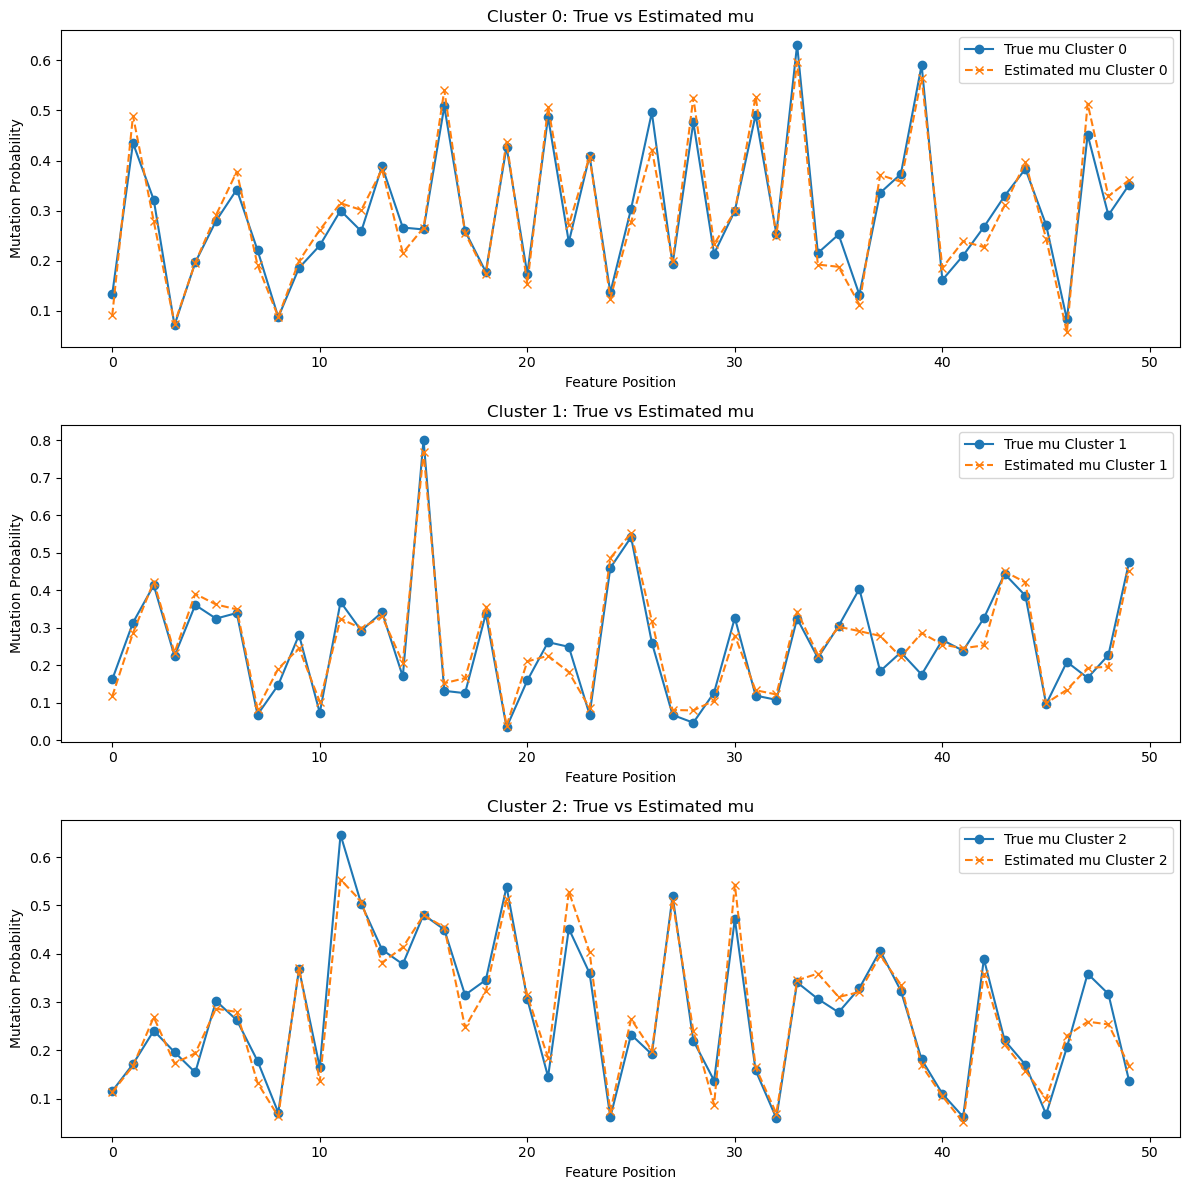

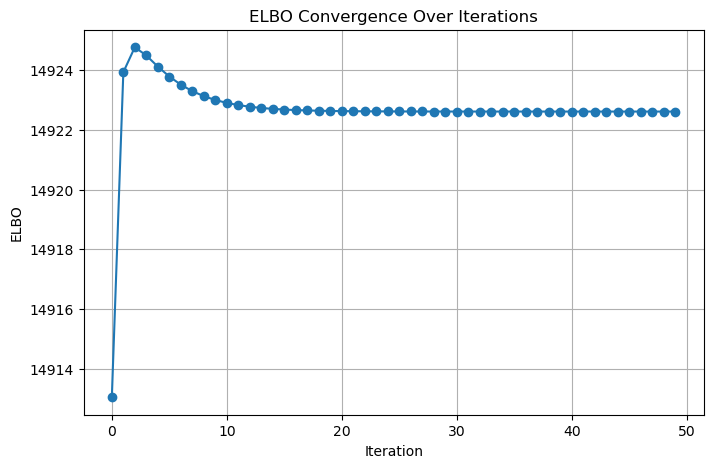

In [6]:
# ==========================
# REQUIRED IMPORTS
# ==========================
import numpy as np
from sklearn.metrics import confusion_matrix, adjusted_rand_score
from scipy.optimize import linear_sum_assignment
from scipy.special import rel_entr
import pandas as pd
import matplotlib.pyplot as plt

# ==========================
# HUNGARIAN MATCH FUNCTION
# ==========================
def hungarian_match(Z_true, Z_pred, K):
    """Match predicted clusters to true clusters via Hungarian algorithm."""
    cm = confusion_matrix(Z_true, Z_pred, labels=np.arange(K))
    row_ind, col_ind = linear_sum_assignment(-cm)
    mapping = dict(zip(col_ind, row_ind))

    # Remap predicted labels according to mapping
    Z_pred_aligned = np.array([mapping[z] for z in Z_pred])

    # Reorder pi and mu to match
    pi_inferred_aligned = pi_inferred[np.array(list(mapping.keys()))]
    mu_inferred_aligned = mu_inferred[np.array(list(mapping.keys()))]

    return Z_pred_aligned, pi_inferred_aligned, mu_inferred_aligned, mapping

# ==========================
# ALIGN CLUSTERS
# ==========================
Z_pred_aligned, pi_inferred_aligned, mu_inferred_aligned, mapping = hungarian_match(Z_true, Z_pred, K)

# ==========================
# EVALUATION METRICS
# ==========================
# Adjusted Rand Index (ARI)
ari_score = adjusted_rand_score(Z_true, Z_pred_aligned)
print(f"Adjusted Rand Index (ARI): {ari_score:.4f}")

# Mean Absolute Error (MAE) for pi
mae_pi = np.mean(np.abs(pi_true - pi_inferred_aligned))
print(f"Mean Absolute Error (MAE) for pi: {mae_pi:.4f}")

# KL Divergence for mu
def average_kl_divergence(true_mu, inferred_mu, epsilon=1e-10):
    kl_divs = []
    for k in range(K):
        kl = np.sum(rel_entr(true_mu[k] + epsilon, inferred_mu[k] + epsilon))
        kl_divs.append(kl)
    return np.mean(kl_divs)

kl_mu = average_kl_divergence(mu_true, mu_inferred_aligned)
print(f"Average KL Divergence for mu: {kl_mu:.4f}")

# ==========================
# VISUALIZATION: MU DISTRIBUTIONS
# ==========================
fig, axes = plt.subplots(K, 1, figsize=(12, 4 * K))

for k in range(K):
    ax = axes[k] if K > 1 else axes
    ax.plot(mu_true[k], label=f'True mu Cluster {k}', linestyle='-', marker='o')
    ax.plot(mu_inferred_aligned[k], label=f'Estimated mu Cluster {k}', linestyle='--', marker='x')
    ax.set_title(f'Cluster {k}: True vs Estimated mu')
    ax.set_xlabel('Feature Position')
    ax.set_ylabel('Mutation Probability')
    ax.legend()

plt.tight_layout()
plt.show()

# ==========================
# ELBO PLOT (OPTIONAL)
# ==========================
plt.figure(figsize=(8, 5))
plt.plot(vi_model.elbo_values, marker='o')
plt.title("ELBO Convergence Over Iterations")
plt.xlabel("Iteration")
plt.ylabel("ELBO")
plt.grid(True)
plt.show()



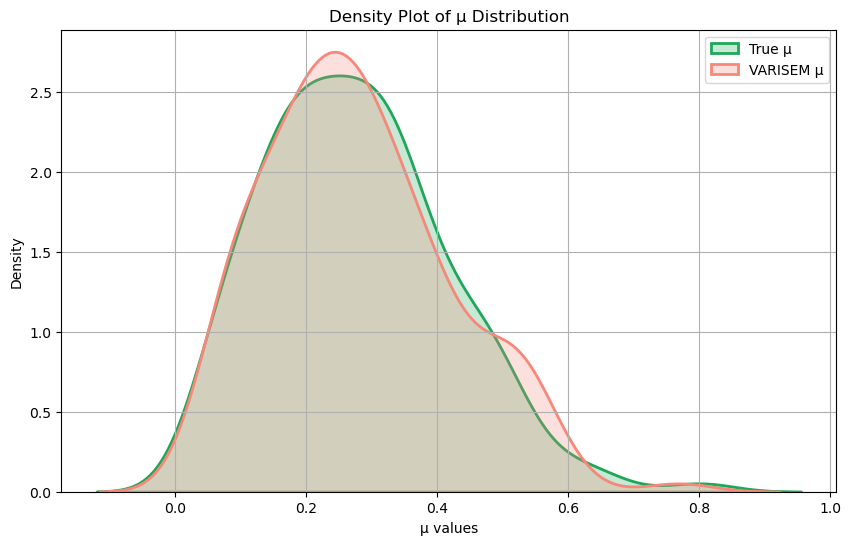

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming you already have these variables:
# mu_true        -> (K=3, D)
# mu_inferred    -> (K=3, D) from VARISEM
# dreem_model.mu -> (K=3, D) from DREEM

# Plotting the density of the μ values
plt.figure(figsize=(10, 6))

# Flatten arrays and plot combined densities
sns.kdeplot(mu_true.flatten(), label='True μ', fill=True, color='#1fa759', linewidth=2)
sns.kdeplot(mu_inferred.flatten(), label='VARISEM μ', fill=True, color='#f78779', linewidth=2)

# Customize plot
K = 3
plt.title(f'Density Plot of μ Distribution')
plt.xlabel('μ values')
plt.ylabel('Density')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()
